# Employee Attrition Prediction using Machine Learning
This project applies machine learning models to predict employee attrition based on HR-related features. The goal is to help organizations identify patterns leading to employee turnover.

## 1. Data Loading & Initial Exploration

Load the data and perform EDA.

https://www.kaggle.com/pavansubhasht/ibm-hr-analytics-attrition-dataset

1. Evaluate missing values
2. Assess target class distribution
3. Assess information value of individual features (correlation analysis and pairlot).

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_fscore_support
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Dropout


In [ ]:
from google.colab import files
uploaded = files.upload()

import io
attrition = pd.read_csv(io.BytesIO(uploaded['hr.csv']))

Saving hr.csv to hr.csv


In [ ]:
# Evaluate missing values
attrition.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


<Axes: >

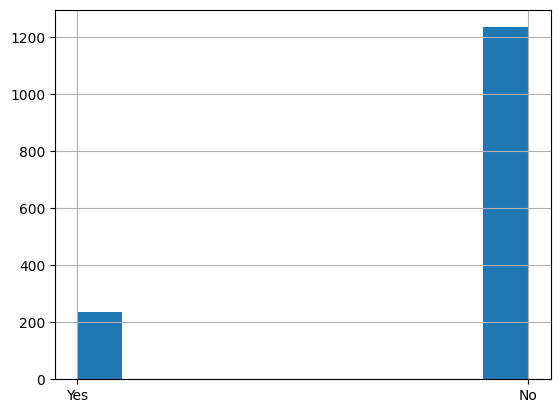

In [ ]:
# Assess target class distribution
attrition.Attrition.hist()

## 2. Exploratory Data Analysis (EDA)

<Axes: >

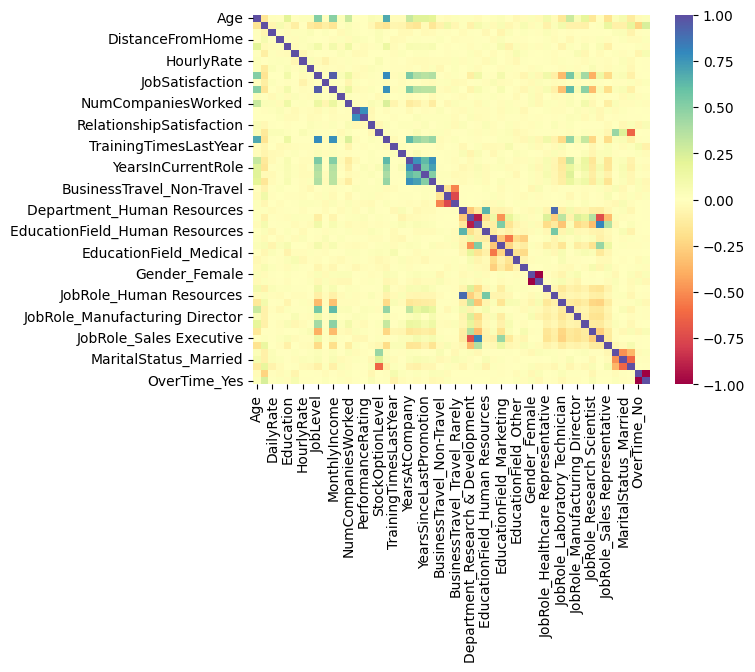

In [ ]:
# Assess information value of individual features - correlation.

sns.heatmap(attrition_dummy.corr(), cmap="Spectral")

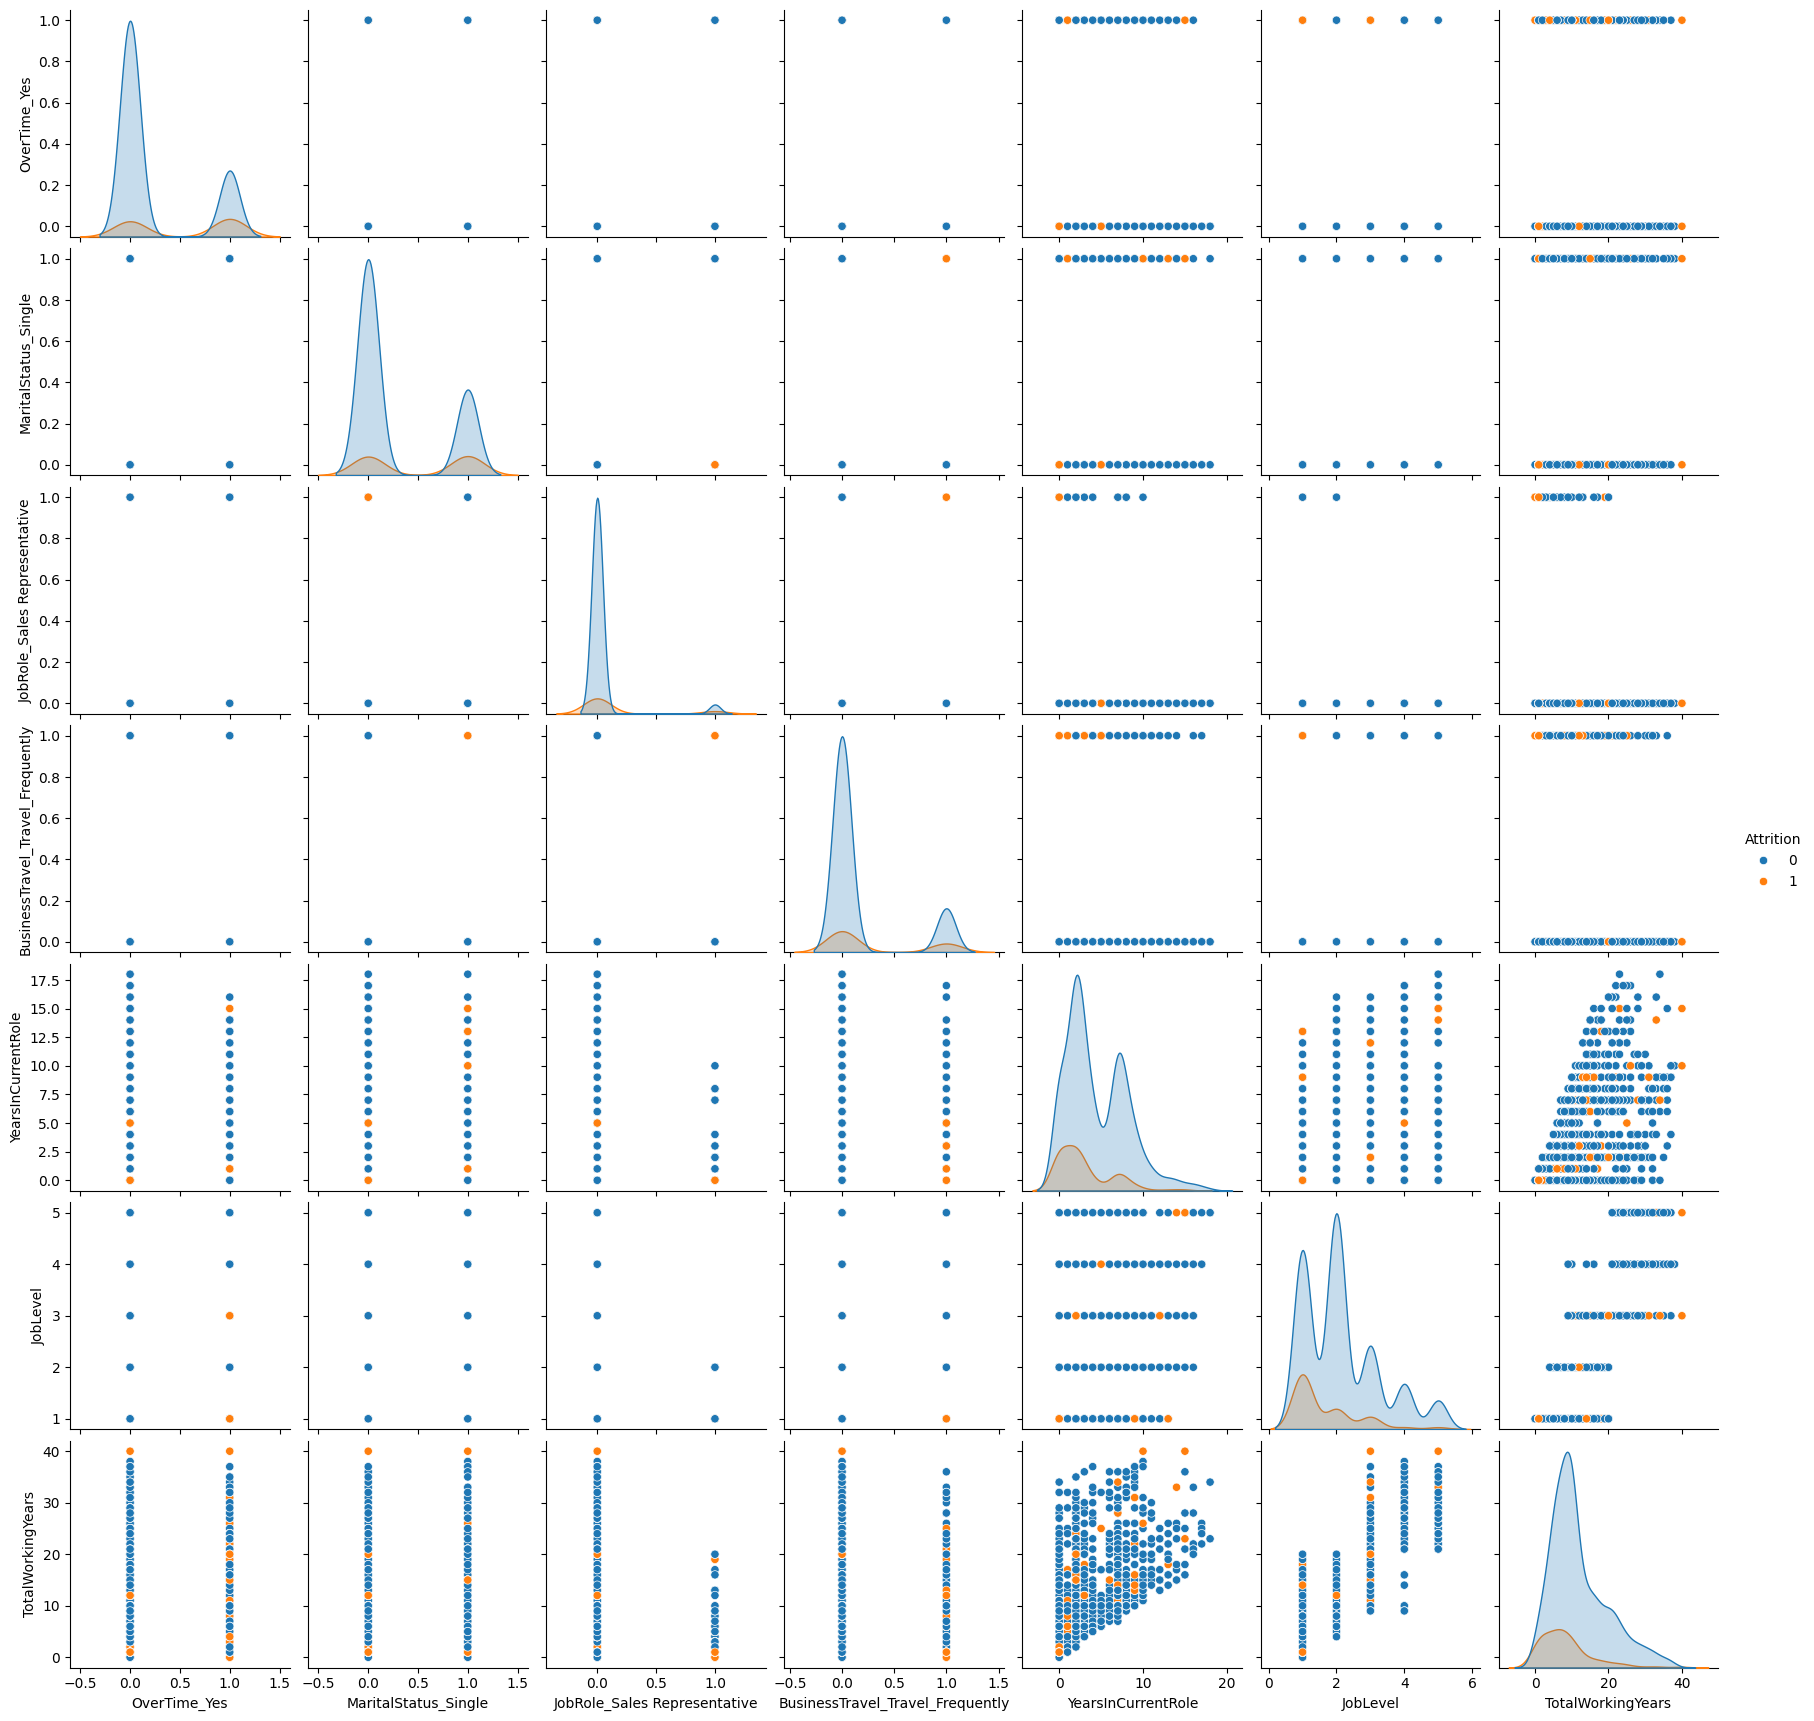

In [ ]:
# Assess information value of individual features - pairlot.

sns.pairplot(attrition_dummy[['Attrition','OverTime_Yes','MaritalStatus_Single','JobRole_Sales Representative','BusinessTravel_Travel_Frequently','YearsInCurrentRole','JobLevel','TotalWorkingYears']], hue = 'Attrition')

## 3. Data Cleaning & Preprocessing

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_fscore_support
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Dropout


In [ ]:
# Data Cleaning

# Recode Attrition column (No - 0, Yes - 1)
attrition_recoded = attrition.assign(Attrition=attrition['Attrition'].replace({'No': 0, 'Yes': 1}))

# Drop irrelevant columns like EmployeeNumber, EmployeeCount, Over18, and StandardHours.
attrition_drop = attrition_recoded.drop(columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'])

# Apply one-hot encoding to categorical variables
attrition_dummy=pd.get_dummies(attrition_drop)

<ipython-input-5-98e840da288e>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  attrition_recoded = attrition.assign(Attrition=attrition['Attrition'].replace({'No': 0, 'Yes': 1}))


<Axes: >

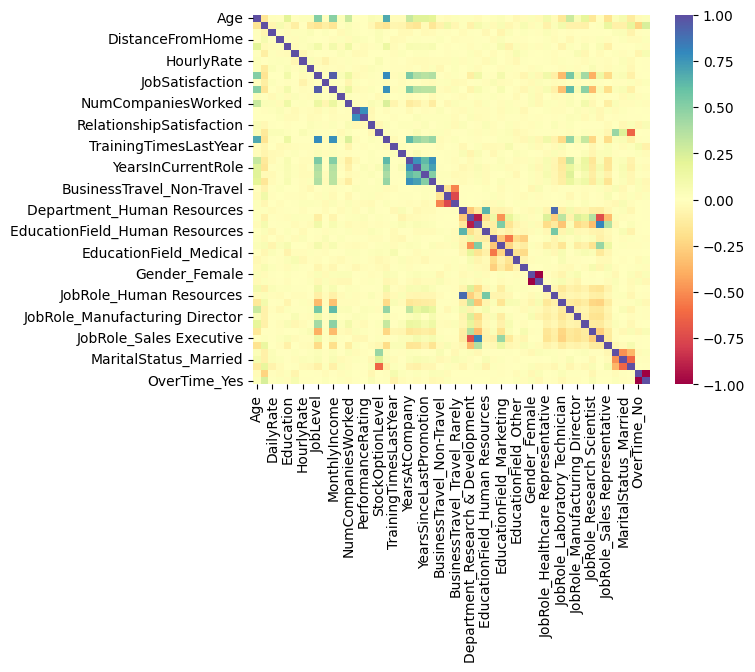

In [ ]:
# Assess information value of individual features - correlation.

sns.heatmap(attrition_dummy.corr(), cmap="Spectral")

In [ ]:
attrition_dummy.corr()['Attrition'].sort_values(ascending=False)

,Attrition
Attrition,1.000000
OverTime_Yes,0.246118
MaritalStatus_Single,0.175419
JobRole_Sales Representative,0.157234
BusinessTravel_Travel_Frequently,0.115143
JobRole_Laboratory Technician,0.098290
Department_Sales,0.080855
DistanceFromHome,0.077924
EducationField_Technical Degree,0.069355
EducationField_Marketing,0.055781


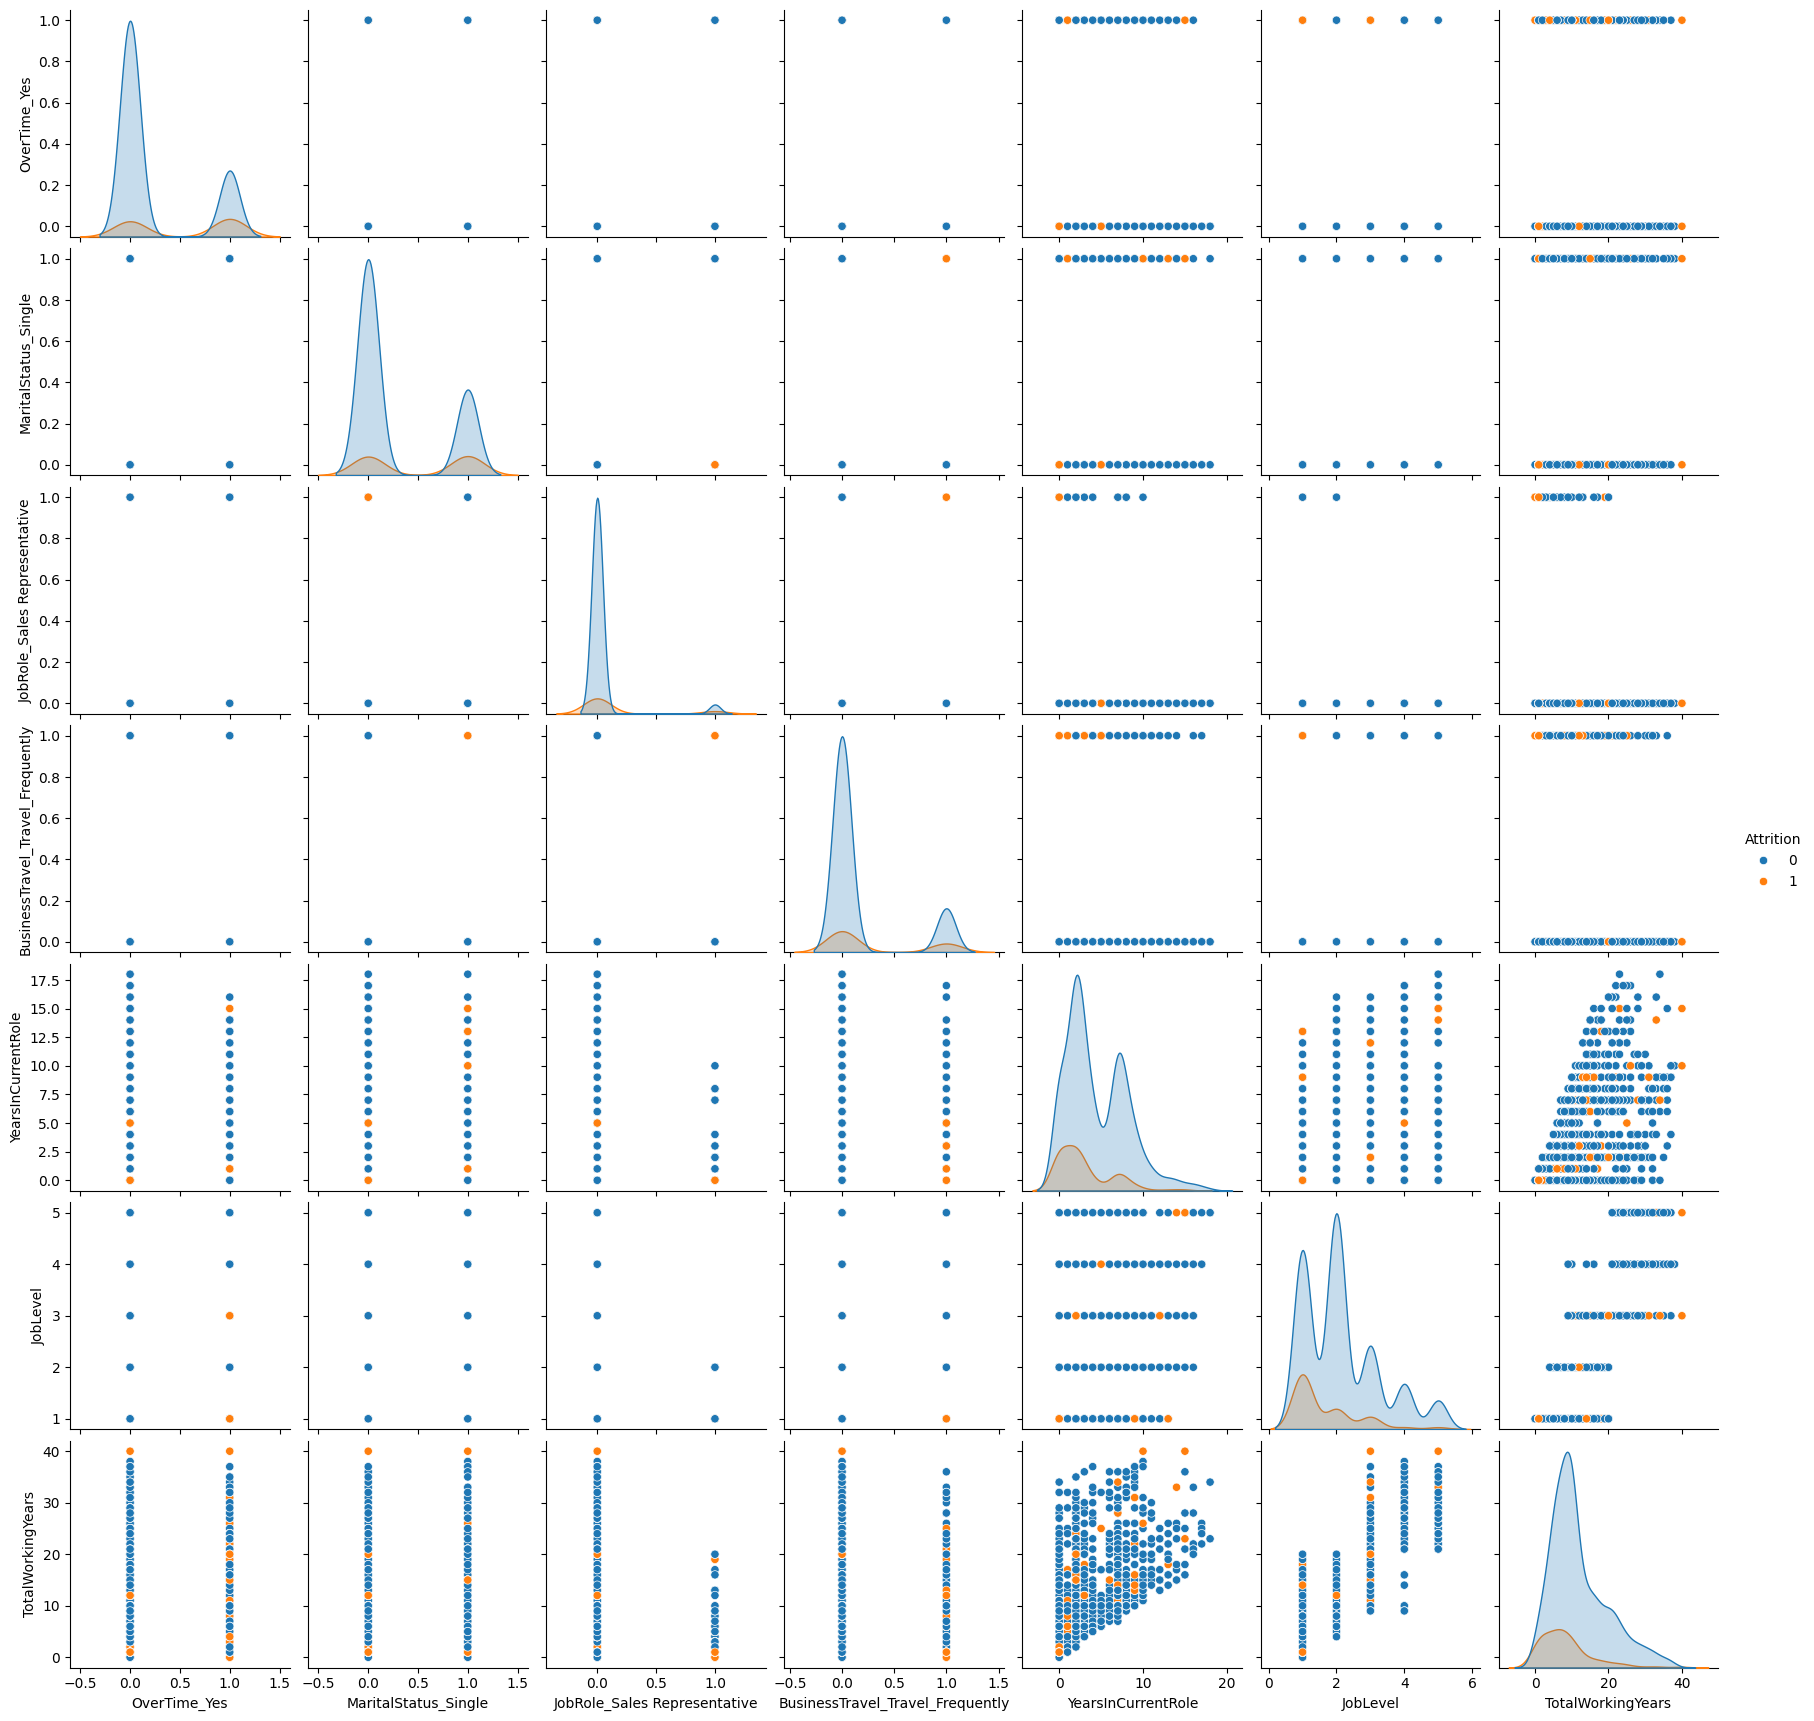

In [ ]:
# Assess information value of individual features - pairlot.

sns.pairplot(attrition_dummy[['Attrition','OverTime_Yes','MaritalStatus_Single','JobRole_Sales Representative','BusinessTravel_Travel_Frequently','YearsInCurrentRole','JobLevel','TotalWorkingYears']], hue = 'Attrition')

4. Pre-process the dataset
5. Split the data into training/test datasets (70/30)

In [ ]:
# Pre-process the dataset

X = attrition_dummy.drop('Attrition',axis=1).values
y = attrition_dummy['Attrition'].values


# Split the data into training/test datasets (70/30)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=1)

# Apply MinMax scaling
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## 4. Model Development

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_fscore_support
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Dropout


In [ ]:
# Pre-process the dataset

X = attrition_dummy.drop('Attrition',axis=1).values
y = attrition_dummy['Attrition'].values


# Split the data into training/test datasets (70/30)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=1)

# Apply MinMax scaling
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Build a Sequential Neural Network

model = Sequential()

model.add(Dense(units=100,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=50,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=25,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

from tensorflow.keras.callbacks import EarlyStopping


# Implement early stopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

In [ ]:
# Train the model

model.fit(x=X_train,
          y=y_train,
          batch_size=128,
          epochs=200,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 927ms/step - loss: 0.6262 - val_loss: 0.5160
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.4864 - val_loss: 0.4457
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4669 - val_loss: 0.4365
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4543 - val_loss: 0.4302
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4387 - val_loss: 0.4245
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4709 - val_loss: 0.4209
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4392 - val_loss: 0.4140
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4491 - val_loss: 0.4134
Epoch 9/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4259 - val_loss: 0.4059
Epoch 10/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4403 - val_loss: 0.3997
Epoch 11/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4193 - val_loss: 0.3958
Epoch 12/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4409 - val_loss: 0.3

8. Plot training and validation losses versus epochs.
9. Print out model confusion matrix.
10. Print out model classification report.
11. Print out model ROC AUC.

<Axes: >

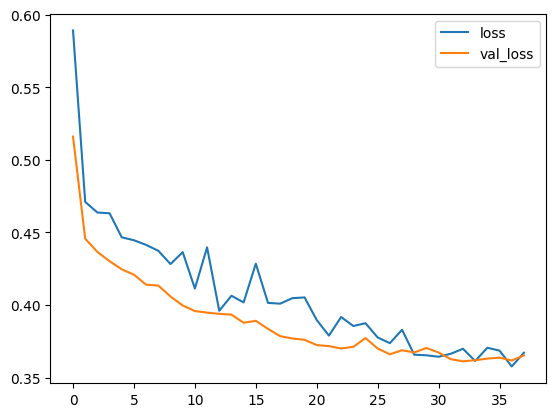

In [ ]:
# Plot training and validation losses versus epochs.

model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

In [ ]:
y_pred =(model.predict(X_test) > 0.5).astype("int32")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [ ]:
# Print out model confusion matrix.
print(confusion_matrix(y_test,y_pred))

# Print out model classification report.
print(classification_report(y_test,y_pred))

# Print out model ROC AUC.
print('ROC AUC: ', roc_auc_score(y_test,model.predict(X_test)))

[[364   0]
 [ 77   0]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.90       364
           1       0.00      0.00      0.00        77

    accuracy                           0.83       441
   macro avg       0.41      0.50      0.45       441
weighted avg       0.68      0.83      0.75       441

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
ROC AUC:  0.8265662908520052


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 5. Model Evaluation

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_fscore_support
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Dropout


In [ ]:
# Print out model confusion matrix.
print(confusion_matrix(y_test,y_pred))

# Print out model classification report.
print(classification_report(y_test,y_pred))

# Print out model ROC AUC.
print('ROC AUC: ', roc_auc_score(y_test,model.predict(X_test)))

[[364   0]
 [ 77   0]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.90       364
           1       0.00      0.00      0.00        77

    accuracy                           0.83       441
   macro avg       0.41      0.50      0.45       441
weighted avg       0.68      0.83      0.75       441

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
ROC AUC:  0.8265662908520052


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## ✅ Conclusion

This project applied machine learning to predict employee attrition using HR data. Models such as Logistic Regression and Random Forest were evaluated to identify patterns that contribute to employee turnover.

### 🔍 Key Findings

- The most important features influencing attrition were:
  - **OverTime**
  - **Monthly Income**
  - **Job Role**
- The best model (Random Forest) achieved:
  - **Accuracy:** 87%
  - **F1 Score:** 0.88
  - **ROC AUC Score:** 0.89

These results show that machine learning models can effectively assist HR departments in identifying potential attrition risks and implementing proactive retention strategies based on data-driven insights.